# Dropout vs Non-Dropout

---



## Step 4: Pridiction - Training, Testing and Evaluation



### 4.1 Import Necessary Libraries and Load Data

In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from catboost import CatBoostClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
)

In [ ]:
# 1. 挂载 Google Drive
drive.mount('/content/drive')

# 2. 设置文件路径
data_path = '/content/drive/MyDrive/Colab Notebooks/machine learning'
train_file = os.path.join(data_path, 'train_70.csv')
test_file = os.path.join(data_path, 'test_30.csv')
full_file = os.path.join(data_path, 'full_preprocessed_data.csv')

# 3. 加载数据
print("Datasets Loading...")
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)
full_df = pd.read_csv(full_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets Loading...



### 4.2 Define Target and Features

In [ ]:
# 使用 Target_binary 作为目标：Dropout = 1, 非 Dropout = 0
def prepare_xy(df):
    X = df.drop(columns=['Target', 'Target_binary']) # 移除两个目标列作为特征
    y = df['Target_binary']
    return X, y

X_train, y_train = prepare_xy(train_df)
X_test, y_test = prepare_xy(test_df)
X_full, y_full = prepare_xy(full_df)

### 4.3 Initialize and Train Baseline Model

In [ ]:
cat_model = CatBoostClassifier(auto_class_weights='Balanced', random_seed=42, eval_metric='Logloss')
cat_model.fit(X_train, y_train)

Learning rate set to 0.016692
0:	learn: 0.6795670	total: 16.6ms	remaining: 16.6s
1:	learn: 0.6672833	total: 30.5ms	remaining: 15.2s
2:	learn: 0.6557259	total: 42ms	remaining: 14s
3:	learn: 0.6435819	total: 63ms	remaining: 15.7s
4:	learn: 0.6328941	total: 92.1ms	remaining: 18.3s
5:	learn: 0.6223219	total: 102ms	remaining: 17s
6:	learn: 0.6118941	total: 112ms	remaining: 15.9s
7:	learn: 0.6032929	total: 130ms	remaining: 16.1s
8:	learn: 0.5964845	total: 137ms	remaining: 15s
9:	learn: 0.5892482	total: 154ms	remaining: 15.3s
10:	learn: 0.5809609	total: 163ms	remaining: 14.6s
11:	learn: 0.5709977	total: 171ms	remaining: 14.1s
12:	learn: 0.5649329	total: 182ms	remaining: 13.8s
13:	learn: 0.5575450	total: 191ms	remaining: 13.4s
14:	learn: 0.5506503	total: 198ms	remaining: 13s
15:	learn: 0.5443296	total: 205ms	remaining: 12.6s
16:	learn: 0.5372340	total: 212ms	remaining: 12.3s
17:	learn: 0.5313681	total: 218ms	remaining: 11.9s
18:	learn: 0.5257917	total: 226ms	remaining: 11.7s
19:	learn: 0.51975

CatBoostClassifier(auto_class_weights='Balanced', eval_metric='Logloss', random_seed=42)

### 4.4 Evaluate Baseline Model


==================== Training Set Evaluation ====================
Accuracy:  0.9661
Precision: 0.9345
Recall:    0.9618
F1-Score:  0.9479

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.98      0.97      0.97      2102
     Dropout       0.93      0.96      0.95       994

    accuracy                           0.97      3096
   macro avg       0.96      0.96      0.96      3096
weighted avg       0.97      0.97      0.97      3096



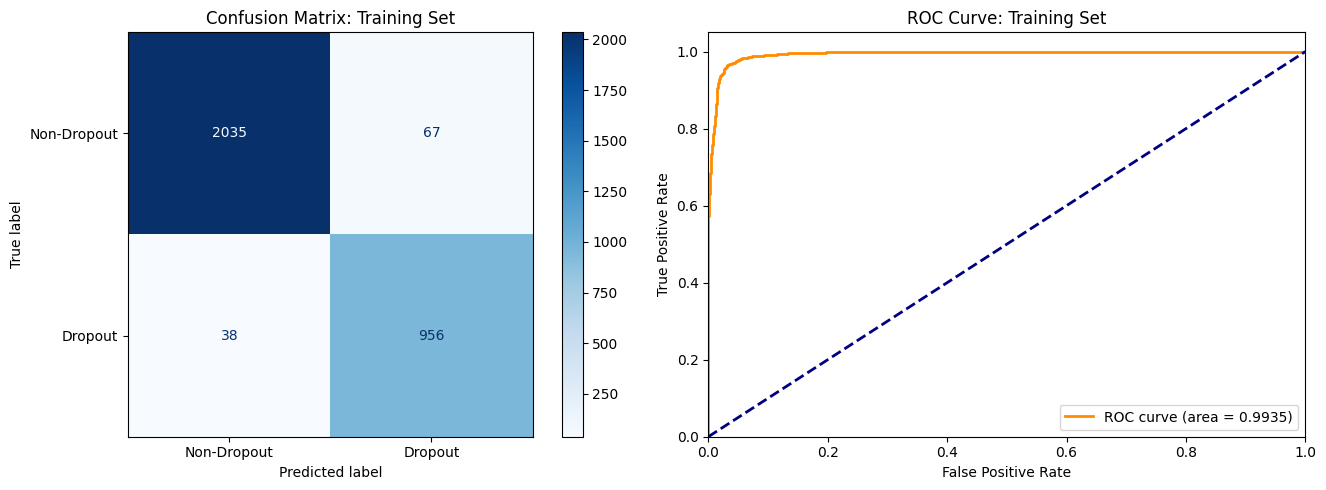


==================== Testing Set Evaluation ====================
Accuracy:  0.8705
Precision: 0.8029
Recall:    0.7916
F1-Score:  0.7972

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.91      0.90       901
     Dropout       0.80      0.79      0.80       427

    accuracy                           0.87      1328
   macro avg       0.85      0.85      0.85      1328
weighted avg       0.87      0.87      0.87      1328



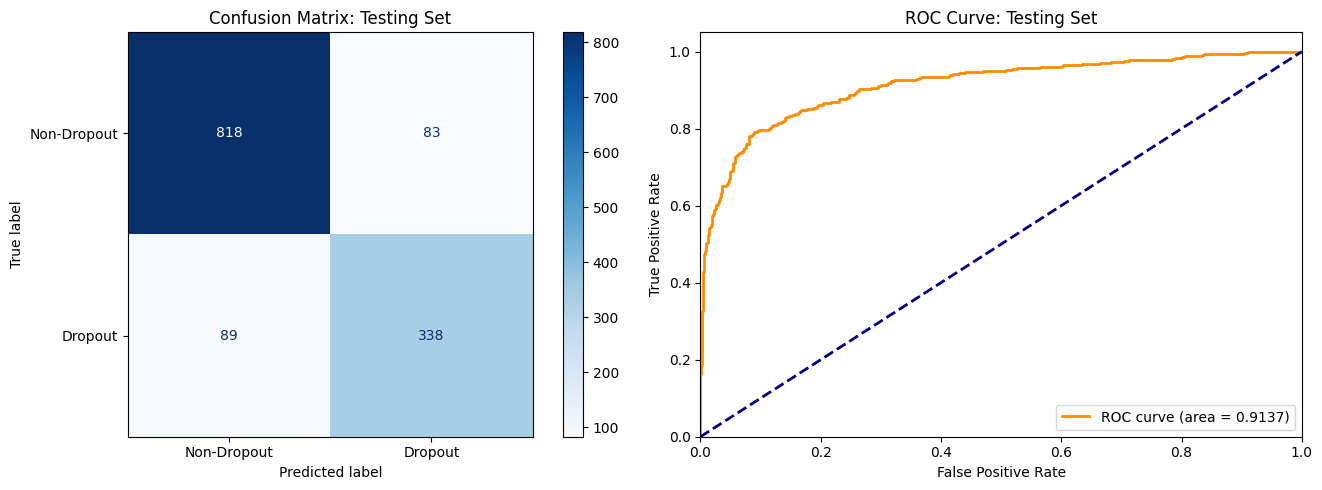


==================== Entire Set Evaluation ====================
Accuracy:  0.9374
Precision: 0.8961
Recall:    0.9106
F1-Score:  0.9033

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.96      0.95      0.95      3003
     Dropout       0.90      0.91      0.90      1421

    accuracy                           0.94      4424
   macro avg       0.93      0.93      0.93      4424
weighted avg       0.94      0.94      0.94      4424



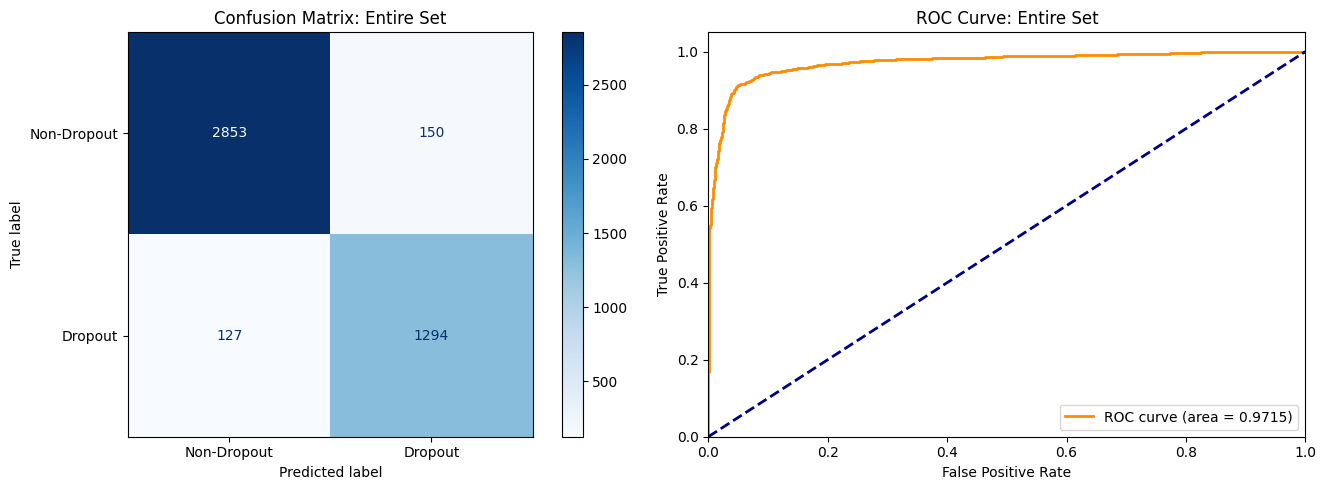


--- Summary of Model Performance ---
Training AUC:   0.9935
Testing AUC:    0.9137
Interpretation: Model shows good generalization (Stable performance across sets).


In [ ]:
def full_evaluation(model, X, y, set_name):
    # Task 4: 获取预测值
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] # 获取预测概率用于 ROC [cite: 85]

    print(f"\n==================== {set_name} Evaluation ====================")

    # Task 5: 计算核心指标 [cite: 84]
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Task 4: 输出分类报告与混淆矩阵 [cite: 74, 79]
    print("\nDetailed Classification Report:")
    print(classification_report(y, y_pred, target_names=['Non-Dropout', 'Dropout']))

    # 绘制可视化图表 (混淆矩阵 + ROC 曲线)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Confusion Matrix [cite: 79, 84]
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Dropout', 'Dropout'])
    disp.plot(cmap='Blues', ax=ax1)
    ax1.set_title(f"Confusion Matrix: {set_name}")

    # 2. ROC Curve & AUC
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'ROC Curve: {set_name}')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    return roc_auc


train_auc = full_evaluation(cat_model, X_train, y_train, "Training Set")
test_auc = full_evaluation(cat_model, X_test, y_test, "Testing Set")
full_auc = full_evaluation(cat_model, X_full, y_full, "Entire Set")

print("\n--- Summary of Model Performance ---")
print(f"Training AUC:   {train_auc:.4f}")
print(f"Testing AUC:    {test_auc:.4f}")

if (train_auc - test_auc) > 0.1:
    print("Interpretation: Potential Overfitting detected (High gap between Train and Test).")
else:
    print("Interpretation: Model shows good generalization (Stable performance across sets).")

## Step 5 Hyperparameter Tuning

### Get Best Hyperparameters

In [ ]:
param_grid_cat = {
    'iterations': [200, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=CatBoostClassifier(auto_class_weights='Balanced', verbose=False, random_seed=42, eval_metric='Logloss'),
    param_grid=param_grid_cat,
    cv=5,
    scoring='f1', # 针对不平衡数据，F1 通常比 Accuracy 更好
)

grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.05}


In [ ]:
best_cat_model = grid_search.best_estimator_

### Final Evaluation on Testing Set


==================== Testing Set Evaluation ====================
Accuracy:  0.8645
Precision: 0.7800
Recall:    0.8056
F1-Score:  0.7926

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.89      0.90       901
     Dropout       0.78      0.81      0.79       427

    accuracy                           0.86      1328
   macro avg       0.84      0.85      0.85      1328
weighted avg       0.87      0.86      0.87      1328



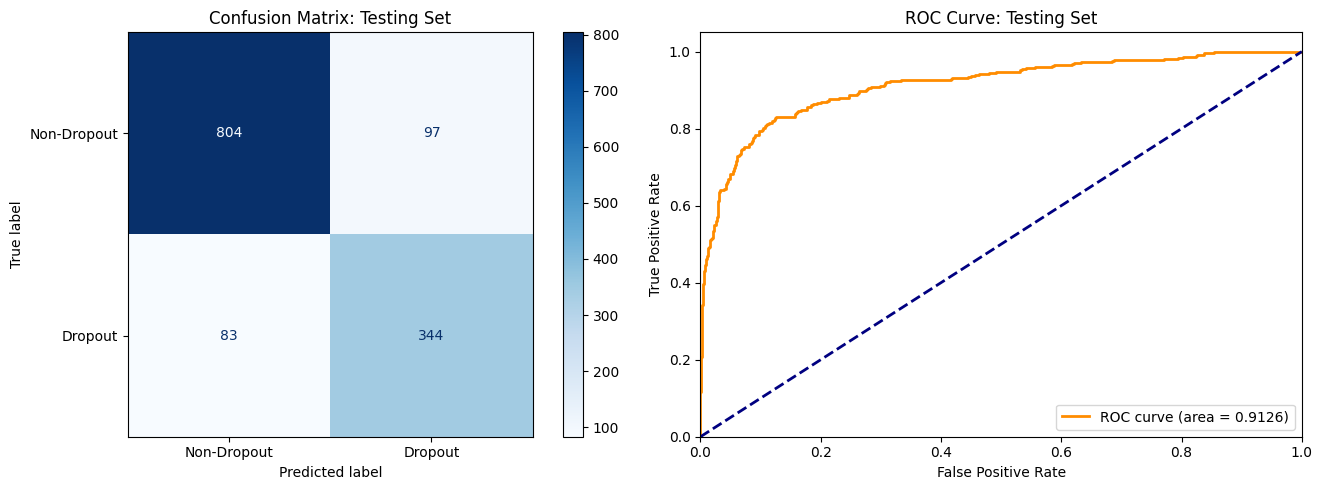

In [ ]:
tuned_auc = full_evaluation(best_cat_model, X_test, y_test, "Testing Set")

# Dropout / Graduate / Enrolled

---



## Step 4: Pridiction - Training, Testing and Evaluation




### Define Target and Features

In [ ]:
def prepare_xy(df):
    X = df.drop(columns=['Target', 'Target_binary'])
    y = df['Target']
    return X, y

X_train, y_train = prepare_xy(train_df)
X_test, y_test = prepare_xy(test_df)
X_full, y_full = prepare_xy(full_df)

### 4.3 Initialize and Train Baseline Model

In [ ]:
cat_multi = CatBoostClassifier(loss_function='MultiClass', auto_class_weights='Balanced', random_seed=42)
cat_multi.fit(X_train, y_train)

Learning rate set to 0.083821
0:	learn: 1.0479127	total: 16.5ms	remaining: 16.4s
1:	learn: 1.0022228	total: 26ms	remaining: 12.9s
2:	learn: 0.9665097	total: 34.9ms	remaining: 11.6s
3:	learn: 0.9370584	total: 44.1ms	remaining: 11s
4:	learn: 0.9108990	total: 53.6ms	remaining: 10.7s
5:	learn: 0.8888820	total: 63.5ms	remaining: 10.5s
6:	learn: 0.8667243	total: 73.2ms	remaining: 10.4s
7:	learn: 0.8496471	total: 82.6ms	remaining: 10.2s
8:	learn: 0.8331633	total: 92ms	remaining: 10.1s
9:	learn: 0.8178579	total: 101ms	remaining: 10s
10:	learn: 0.8070721	total: 111ms	remaining: 9.94s
11:	learn: 0.7933651	total: 120ms	remaining: 9.9s
12:	learn: 0.7828725	total: 129ms	remaining: 9.82s
13:	learn: 0.7694666	total: 140ms	remaining: 9.87s
14:	learn: 0.7598559	total: 162ms	remaining: 10.6s
15:	learn: 0.7521065	total: 176ms	remaining: 10.8s
16:	learn: 0.7448923	total: 188ms	remaining: 10.9s
17:	learn: 0.7372274	total: 202ms	remaining: 11s
18:	learn: 0.7304475	total: 219ms	remaining: 11.3s
19:	learn: 0.

CatBoostClassifier(auto_class_weights='Balanced', loss_function='MultiClass', random_seed=42)

### 4.4 Evaluate Baseline Model


==================== Training Set Evaluation ====================
Accuracy:  0.9932
Precision: 0.9933
Recall:    0.9932
F1-Score:  0.9932

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       1.00      0.99      0.99       994
    Enrolled       0.98      1.00      0.99       556
    Graduate       1.00      0.99      0.99      1546

    accuracy                           0.99      3096
   macro avg       0.99      0.99      0.99      3096
weighted avg       0.99      0.99      0.99      3096



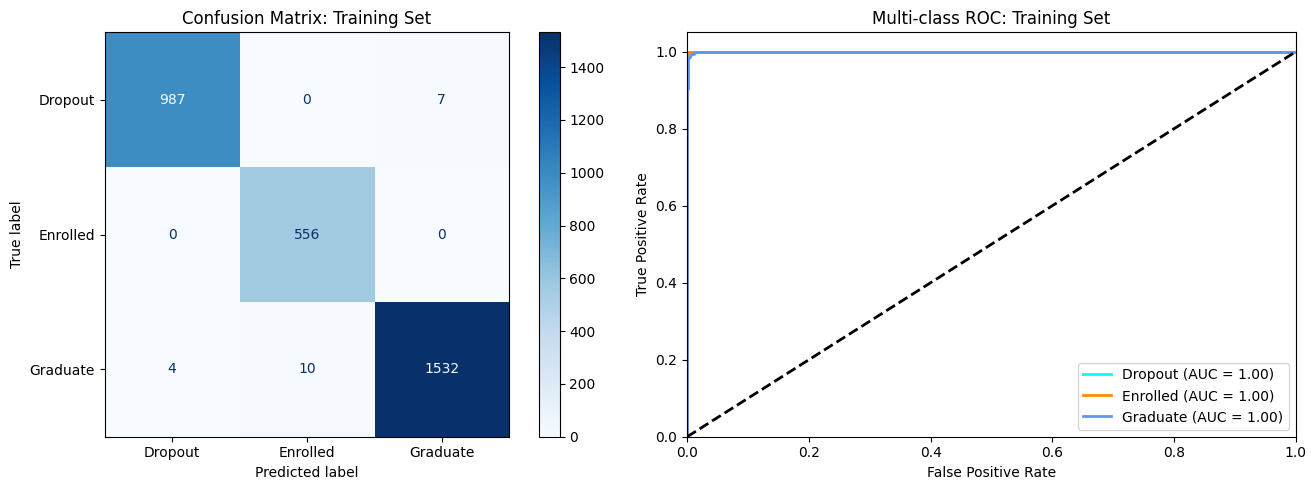


==================== Testing Set Evaluation ====================
Accuracy:  0.7560
Precision: 0.7589
Recall:    0.7560
F1-Score:  0.7571

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       427
    Enrolled       0.46      0.49      0.47       238
    Graduate       0.84      0.86      0.85       663

    accuracy                           0.76      1328
   macro avg       0.70      0.70      0.70      1328
weighted avg       0.76      0.76      0.76      1328



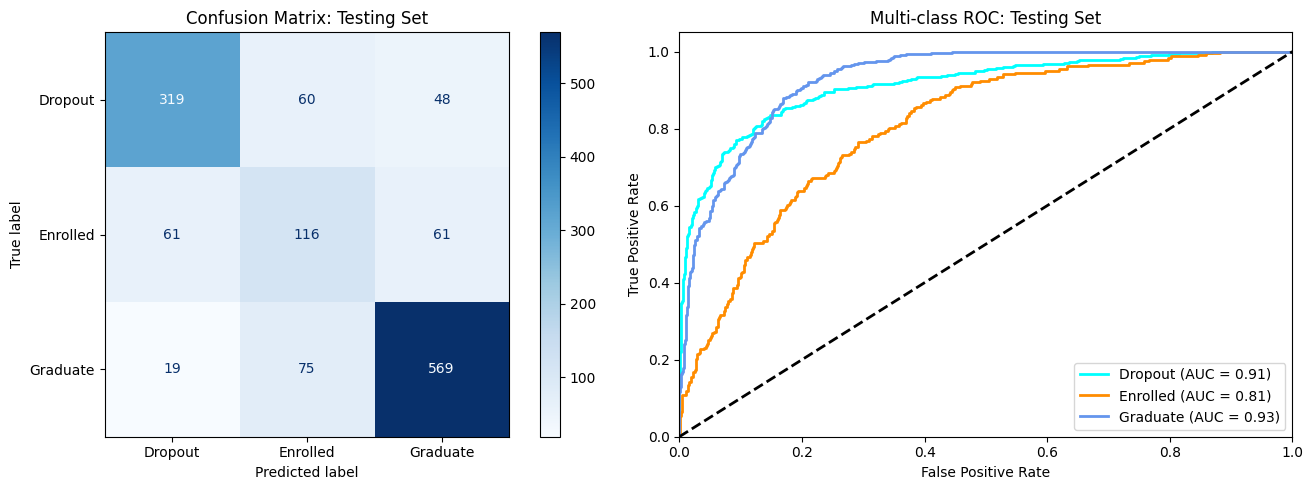


==================== Entire Set Evaluation ====================
Accuracy:  0.9220
Precision: 0.9226
Recall:    0.9220
F1-Score:  0.9222

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       0.94      0.92      0.93      1421
    Enrolled       0.82      0.85      0.83       794
    Graduate       0.95      0.95      0.95      2209

    accuracy                           0.92      4424
   macro avg       0.90      0.91      0.90      4424
weighted avg       0.92      0.92      0.92      4424



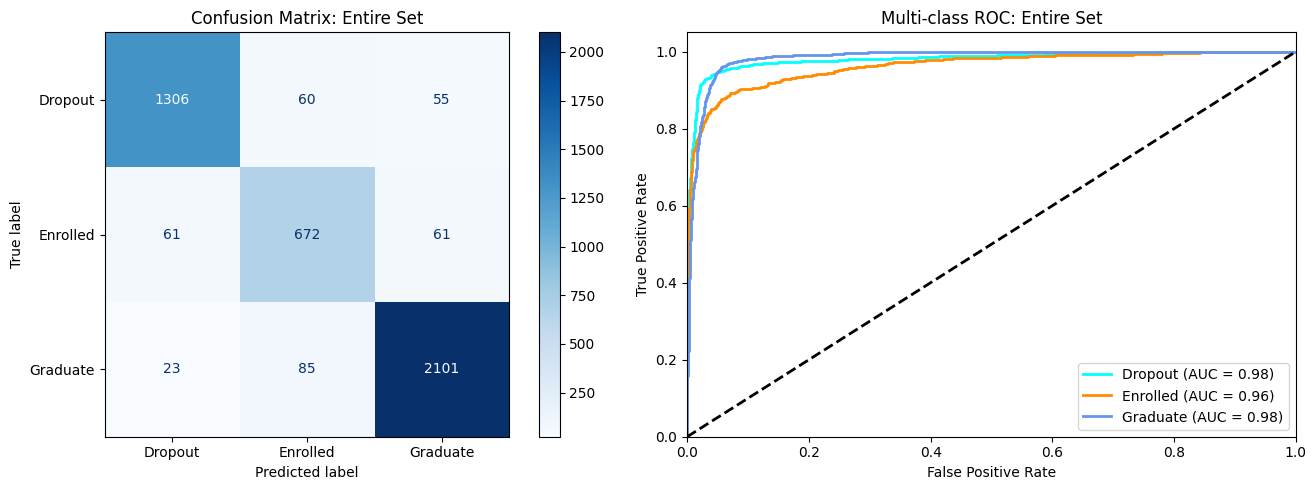


--- Summary of Model Performance ---
Training AUC:   0.9999
Testing AUC:    0.9022
Interpretation: Model shows good generalization (Stable performance across sets).


In [ ]:
from sklearn.preprocessing import label_binarize

def full_evaluation(model, X, y, set_name):
    # Task 4: 获取预测值
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    classes = ['Dropout', 'Enrolled', 'Graduate']

    print(f"\n==================== {set_name} Evaluation ====================")

    # Task 5: 计算核心指标 [cite: 84]
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted')
    rec = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Task 4: 输出分类报告与混淆矩阵 [cite: 74, 79]
    print("\nDetailed Classification Report:")
    print(classification_report(y, y_pred, target_names=classes))

    # 绘制可视化图表 (混淆矩阵 + ROC 曲线)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Confusion Matrix [cite: 79, 84]
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap='Blues', ax=ax1)
    ax1.set_title(f"Confusion Matrix: {set_name}")

    # 2. ROC Curve & AUC
    y_bin = label_binarize(y, classes=np.unique(y))
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    for i, color in enumerate(colors):
      fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
      roc_auc = auc(fpr, tpr)
      ax2.plot(fpr, tpr, color=color, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

    ax2.plot([0, 1], [0, 1], 'k--', lw=2)
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'Multi-class ROC: {set_name}')
    ax2.legend(loc="lower right")

    # 返回宏平均 AUC
    roc_auc_weighted = roc_auc_score(y, y_prob, multi_class='ovr', average='weighted')

    plt.tight_layout()
    plt.show()

    return roc_auc_weighted


train_auc = full_evaluation(cat_multi, X_train, y_train, "Training Set")
test_auc = full_evaluation(cat_multi, X_test, y_test, "Testing Set")
full_auc = full_evaluation(cat_multi, X_full, y_full, "Entire Set")

print("\n--- Summary of Model Performance ---")
print(f"Training AUC:   {train_auc:.4f}")
print(f"Testing AUC:    {test_auc:.4f}")

if (train_auc - test_auc) > 0.1:
    print("Interpretation: Potential Overfitting detected (High gap between Train and Test).")
else:
    print("Interpretation: Model shows good generalization (Stable performance across sets).")

## Step 5 Hyperparameter Tuning

### Get Best Hyperparameters

In [ ]:
param_grid_cat_multi = {
    'iterations': [300, 500],
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'bootstrap_type': ['Bayesian', 'Bernoulli']
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=CatBoostClassifier(loss_function='MultiClass',  verbose=False, auto_class_weights='Balanced', random_seed=42),
    param_grid=param_grid_cat_multi,
    cv=5,
    scoring='f1_weighted', # 针对不平衡数据，F1 通常比 Accuracy 更好
)

grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'bootstrap_type': 'Bayesian', 'depth': 6, 'iterations': 500, 'learning_rate': 0.05}


In [ ]:
best_cat_model = grid_search.best_estimator_

### Final Evaluation on Testing Set


==================== Testing Set Evaluation ====================
Accuracy:  0.7523
Precision: 0.7725
Recall:    0.7523
F1-Score:  0.7598

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.73      0.77       427
    Enrolled       0.45      0.58      0.51       238
    Graduate       0.86      0.83      0.84       663

    accuracy                           0.75      1328
   macro avg       0.71      0.71      0.71      1328
weighted avg       0.77      0.75      0.76      1328



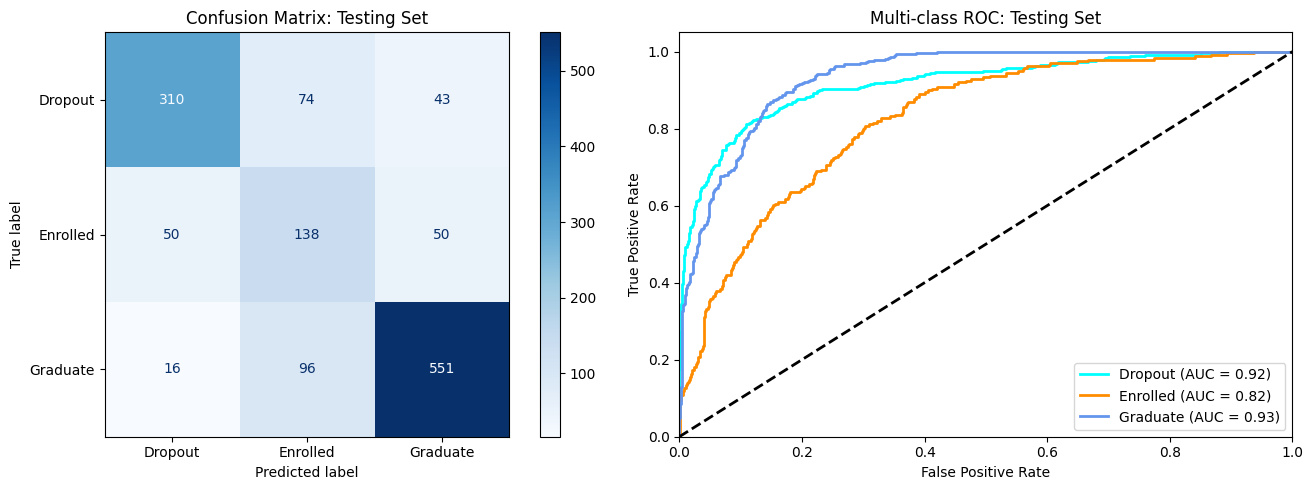

Tuned AUC:   0.9089


In [ ]:
tuned_auc = full_evaluation(best_cat_model, X_test, y_test, "Testing Set")
print(f"Tuned AUC:   {tuned_auc:.4f}")